In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import cv2
import os

In [2]:
BASE_DIR=r"D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_classification"

In [3]:
def load_data(split):
    data=[]
    VALID_EXT=(".jpg", ".jpeg", ".png")
    for label in ["real","fake"]:
        folder=os.path.join(BASE_DIR,split,label)
        for img in os.listdir(folder):
            if img.lower().endswith(VALID_EXT):
                data.append({"path":os.path.join(folder,img),"label":label})

    return pd.DataFrame(data)

In [4]:
train_df=load_data("train")
test_df=load_data("test")
val_df=load_data("val")

In [5]:
print(train_df.head())
print(train_df["label"].value_counts())

                                                path label
0  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
1  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
2  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
3  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
4  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
label
real    12848
fake    12848
Name: count, dtype: int64


In [6]:
print(test_df.head())
print(test_df["label"].value_counts())

                                                path label
0  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
1  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
2  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
3  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
4  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
label
real    1606
fake    1606
Name: count, dtype: int64


In [7]:
print(val_df.head())
print(val_df["label"].value_counts())

                                                path label
0  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
1  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
2  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
3  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
4  D:\SEM-6\DL\DEEP-FAKE\DataSets\deepfake_face_c...  real
label
real    1606
fake    1606
Name: count, dtype: int64


In [8]:
print("Train:", train_df.shape)
print("Valid:", val_df.shape)
print("Test :", test_df.shape)

Train: (25696, 2)
Valid: (3212, 2)
Test : (3212, 2)


In [9]:
def resolution_eda(df, name, plot_sample=4000):

    widths  = np.empty(len(df), dtype=np.int32)
    heights = np.empty(len(df), dtype=np.int32)

    bad = 0

    for i, path in enumerate(tqdm(df["path"], desc=f"{name} scan")):
        try:
            with Image.open(path) as img:
                w, h = img.size
        except:
            w, h = -1, -1
            bad += 1

        widths[i]  = w
        heights[i] = h

    df = df.copy()
    df["width"]  = widths
    df["height"] = heights

    df = df[df["width"] > 0]

    print(f"\n{name} corrupted images:", bad)

    print(f"\n{name} resolution statistics:")
    print(df[["width", "height"]].describe())

    if len(df) > plot_sample:
        plot_df = df.sample(plot_sample, random_state=42)
    else:
        plot_df = df

    plt.figure(figsize=(6,5))
    plt.scatter(
        plot_df["width"],
        plot_df["height"],
        s=4,
        alpha=0.3
    )
    plt.xlabel("Width")
    plt.ylabel("Height")
    plt.title(f"{name} Resolution Distribution")
    plt.show()

    return df


Train scan: 100%|██████████| 25696/25696 [06:07<00:00, 69.84it/s]


Train corrupted images: 0

Train resolution statistics:
              width        height
count  25696.000000  25696.000000
mean     425.948941    429.062267
std      286.431951    283.926321
min      178.000000    218.000000
25%      256.000000    256.000000
50%      256.000000    256.000000
75%      512.000000    512.000000
max     1024.000000   1024.000000


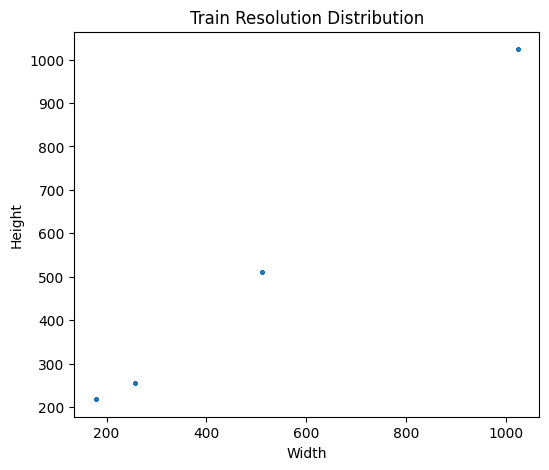

Validation scan: 100%|██████████| 3212/3212 [00:49<00:00, 65.27it/s]


Validation corrupted images: 0

Validation resolution statistics:
             width       height
count  3212.000000  3212.000000
mean    396.911582   396.911582
std     181.993654   181.993654
min     256.000000   256.000000
25%     256.000000   256.000000
50%     256.000000   256.000000
75%     512.000000   512.000000
max    1024.000000  1024.000000


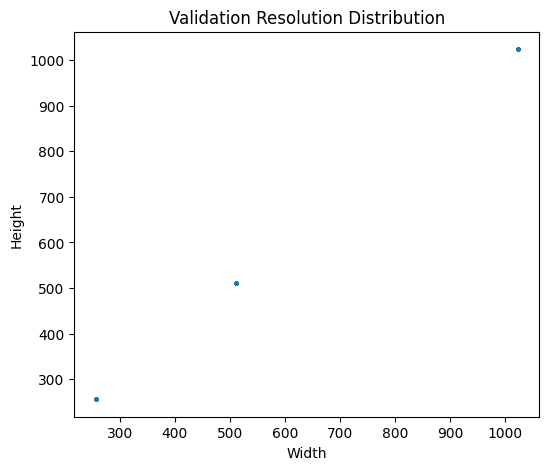

Test scan: 100%|██████████| 3212/3212 [00:50<00:00, 64.24it/s]



Test corrupted images: 0

Test resolution statistics:
             width       height
count  3212.000000  3212.000000
mean    452.144458   452.144458
std     130.889981   130.889981
min     256.000000   256.000000
25%     256.000000   256.000000
50%     512.000000   512.000000
75%     512.000000   512.000000
max    1024.000000  1024.000000


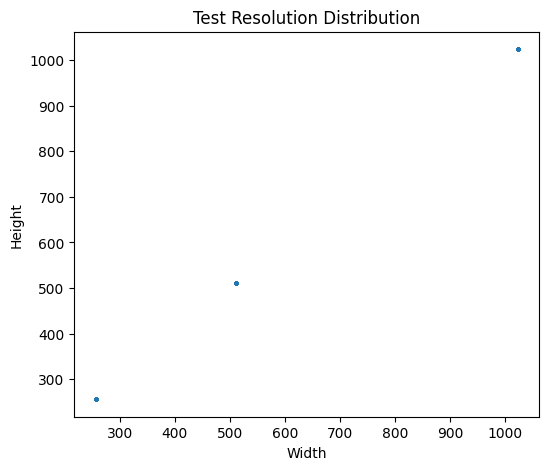

In [10]:
train_res = resolution_eda(train_df, "Train")
val_res   = resolution_eda(val_df, "Validation")
test_res  = resolution_eda(test_df, "Test")

In [11]:
def aspect_ratio_eda(res_df, name):

    res_df["aspect_ratio"] = res_df["width"] / res_df["height"]

    sns.histplot(res_df["aspect_ratio"], bins=50)
    plt.title(f"{name} Aspect Ratio Distribution")
    plt.show()

    print(res_df["aspect_ratio"].describe())


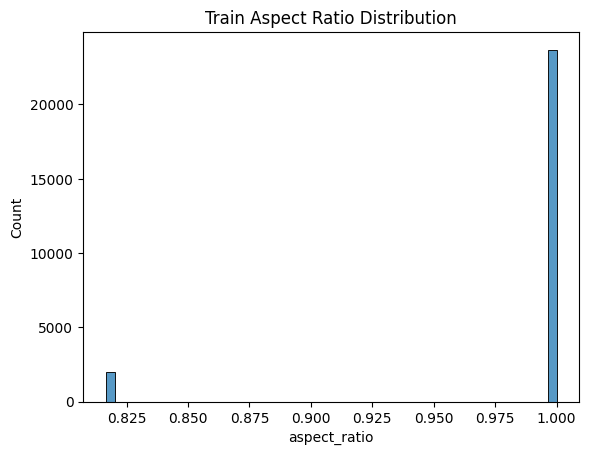

count    25696.000000
mean         0.985719
std          0.049159
min          0.816514
25%          1.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: aspect_ratio, dtype: float64


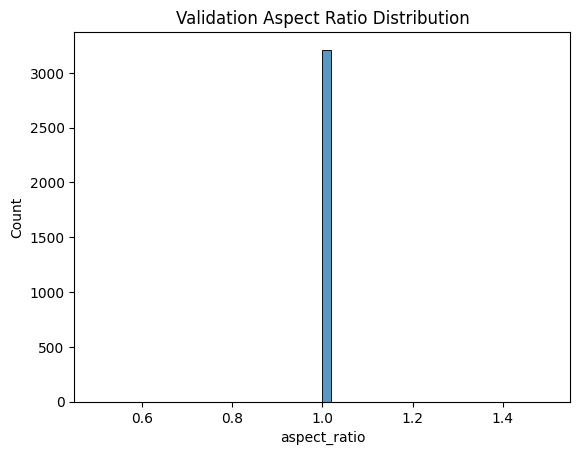

count    3212.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


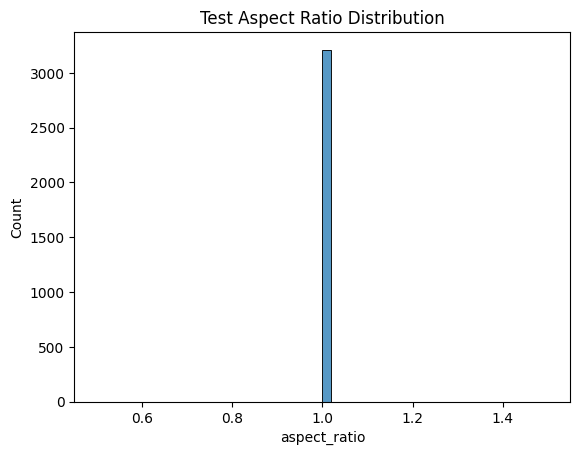

count    3212.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: aspect_ratio, dtype: float64


In [12]:
aspect_ratio_eda(train_res, "Train")
aspect_ratio_eda(val_res, "Validation")
aspect_ratio_eda(test_res, "Test")

In [13]:
def brightness_contrast_eda(df, name, sample=4000):

    sample_size = min(sample, len(df))
    temp = df.sample(sample_size, random_state=42)

    brightness = []
    contrast   = []

    for path in tqdm(temp["path"], desc=f"{name} brightness"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue  # skip broken images

        brightness.append(img.mean())
        contrast.append(img.std())

    temp = temp.iloc[:len(brightness)].copy()
    temp["brightness"] = brightness
    temp["contrast"]   = contrast

    sns.kdeplot(data=temp, x="brightness", hue="label", fill=True)
    plt.title(f"{name} Brightness Distribution")
    plt.show()

    sns.kdeplot(data=temp, x="contrast", hue="label", fill=True)
    plt.title(f"{name} Contrast Distribution")
    plt.show()

Train brightness: 100%|██████████| 4000/4000 [00:18<00:00, 218.66it/s]


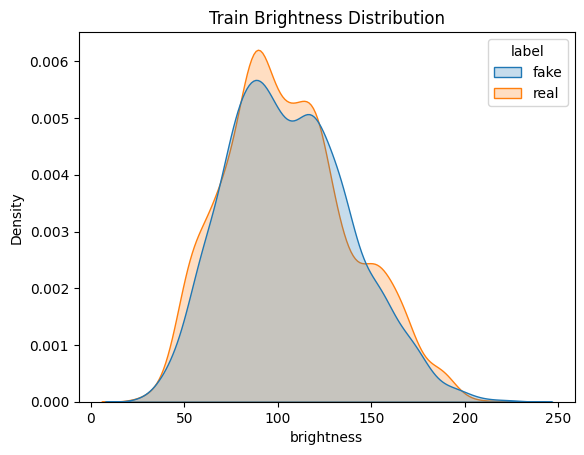

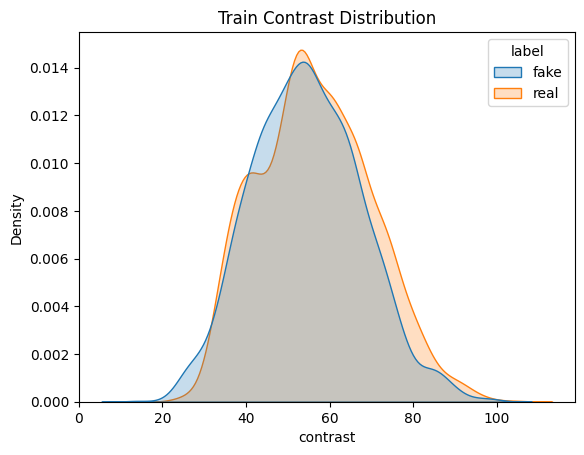

Validation brightness: 100%|██████████| 3212/3212 [00:14<00:00, 225.11it/s]


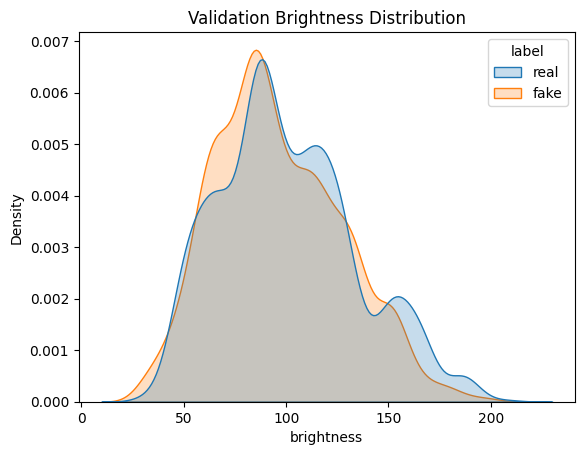

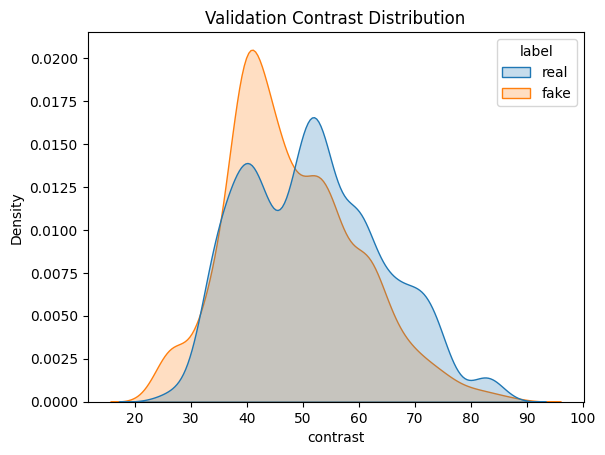

Test brightness: 100%|██████████| 3212/3212 [00:22<00:00, 140.09it/s]


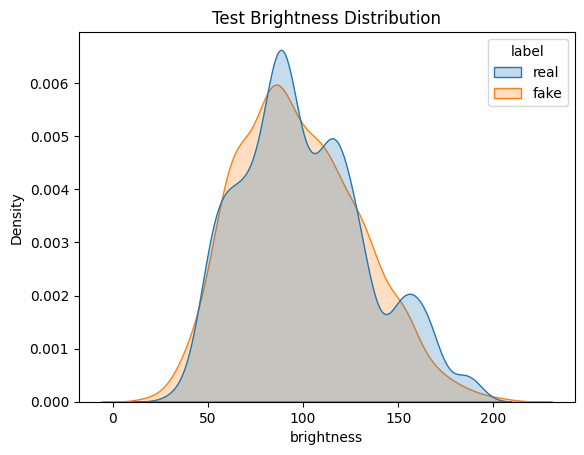

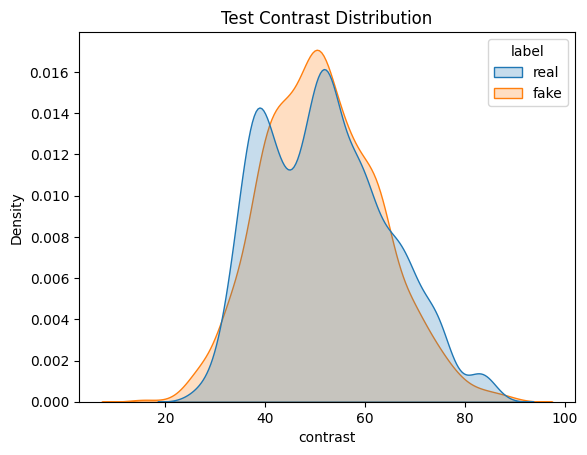

In [14]:
brightness_contrast_eda(train_df, "Train")
brightness_contrast_eda(val_df, "Validation")
brightness_contrast_eda(test_df, "Test")

In [15]:
def rgb_channel_eda(df, name):

    R, G, B = [], [], []

    for path in tqdm(df["path"], desc=f"{name} RGB"):
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        r, g, b = img.mean(axis=(0,1))
        R.append(r); G.append(g); B.append(b)

    plt.figure(figsize=(8,5))
    sns.kdeplot(R, label="R")
    sns.kdeplot(G, label="G")
    sns.kdeplot(B, label="B")
    plt.title(f"{name} RGB Channel Means")
    plt.legend()
    plt.show()

Train RGB: 100%|██████████| 25696/25696 [02:41<00:00, 159.21it/s]


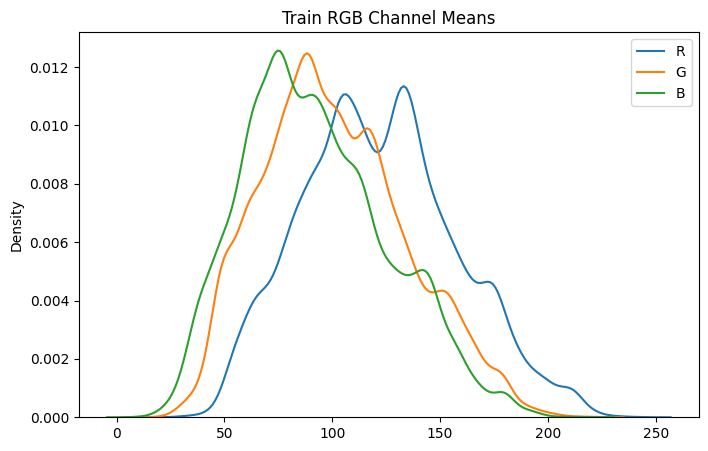

Validate RGB: 100%|██████████| 3212/3212 [00:18<00:00, 175.84it/s]


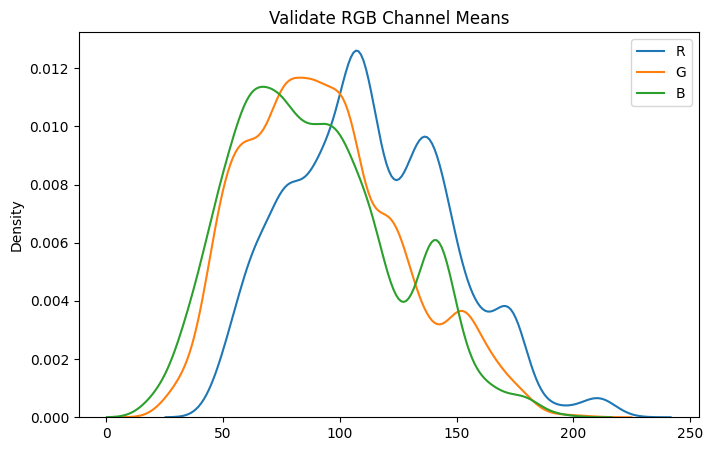

Test RGB: 100%|██████████| 3212/3212 [00:29<00:00, 107.62it/s]


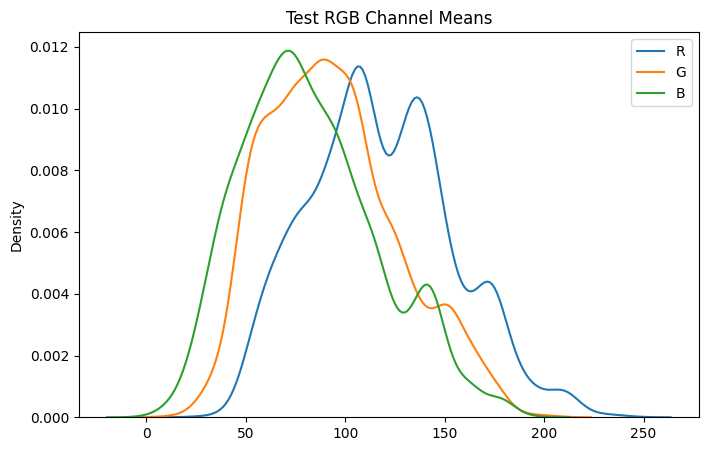

In [16]:
rgb_channel_eda(train_df,"Train")
rgb_channel_eda(val_df,"Validate")
rgb_channel_eda(test_df,"Test")

In [19]:
print(len(train_df), len(val_df), len(test_df))

25696 3212 3212


In [17]:
def fft_energy_eda(df, name, sample=2000):

    n = min(sample, len(df))
    temp = df.sample(n=n, random_state=42)

    def fft_energy(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (256,256))
        f = np.fft.fftshift(np.fft.fft2(img))
        return np.log(np.abs(f) + 1).mean()

    temp = temp.copy()  # avoid SettingWithCopy warnings
    temp["fft_energy"] = [
        fft_energy(p) for p in tqdm(temp["path"], desc=f"{name} FFT")
    ]

    sns.kdeplot(
        data=temp,
        x="fft_energy",
        hue="label",
        fill=True
    )
    plt.title(f"{name} FFT Energy Distribution")
    plt.show()

Train FFT: 100%|██████████| 2000/2000 [00:11<00:00, 171.72it/s]


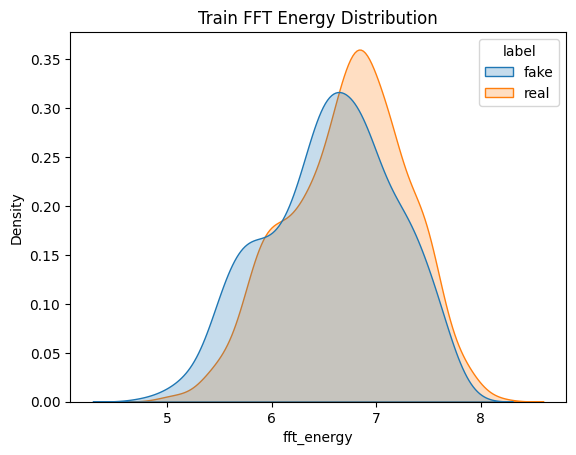

Validate FFT: 100%|██████████| 2000/2000 [00:11<00:00, 171.48it/s]


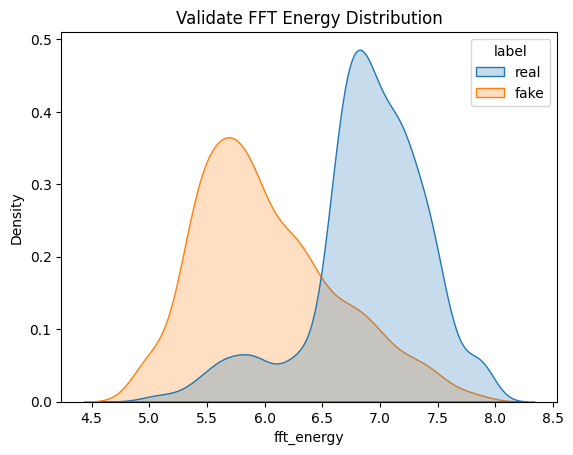

Test FFT: 100%|██████████| 2000/2000 [00:13<00:00, 152.29it/s]


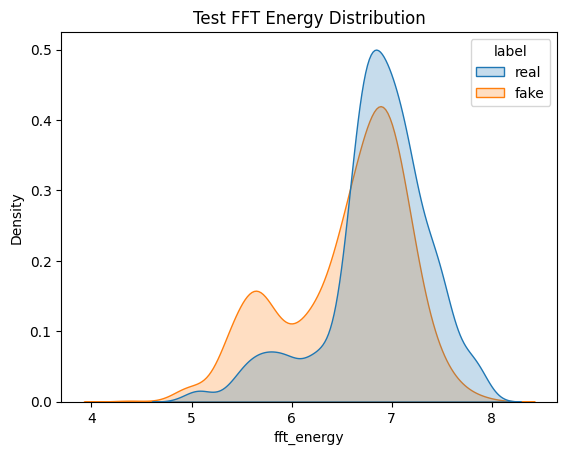

In [18]:
fft_energy_eda(train_df,"Train")
fft_energy_eda(val_df,"Validate")
fft_energy_eda(test_df,"Test")

In [ ]:
def haar_face_presence_eda(df, name, sample=3000):
    """
    Fast face-presence EDA using Haar Cascade.
    Safe for large datasets (140k+ images).

    Parameters:
    - df: DataFrame with columns ['path', 'label']
    - name: dataset name (Train / Validation / Test)
    - sample: number of images to sample
    """

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    assert not face_cascade.empty(), "Haar cascade failed to load"

    temp = df.sample(sample, random_state=42)
    faces = []

    for path in tqdm(temp["path"], desc=f"{name} Haar face check"):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            faces.append(0)
            continue

        detections = face_cascade.detectMultiScale(
            img,
            scaleFactor=1.1,
            minNeighbors=5,
            minSize=(40, 40)
        )

        faces.append(1 if len(detections) > 0 else 0)

    temp = temp.copy()
    temp["face"] = faces

    print(f"\n{name} face presence rate:")
    print(temp.groupby("label")["face"].mean())


In [20]:
haar_face_presence_eda(train_df, "Train")
haar_face_presence_eda(val_df, "Validation")
haar_face_presence_eda(test_df, "Test")

Train Haar face check: 100%|██████████| 3000/3000 [00:34<00:00, 86.04it/s] 



Train face presence rate:
label
fake    0.981583
real    0.908083
Name: face, dtype: float64


Validation Haar face check: 100%|██████████| 3000/3000 [00:30<00:00, 99.68it/s] 



Validation face presence rate:
label
fake    0.994000
real    0.840667
Name: face, dtype: float64


Test Haar face check: 100%|██████████| 3000/3000 [00:34<00:00, 87.61it/s]


Test face presence rate:
label
fake    0.992667
real    0.841333
Name: face, dtype: float64


Pre Processing

In [23]:
OUTPUT_DIR = r"D:\SEM-6\DL\DEEP-FAKE\DataSets\hugging_face_aligned"

In [24]:
def preprocess_image_kaggle_style(src_path, dst_path):
    """
    Preprocess ONE image to Kaggle-aligned format.
    """

    img = cv2.imread(src_path)
    if img is None:
        return False

    # Force RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # HARD resize to 256x256
    img = cv2.resize(img, (256, 256), interpolation=cv2.INTER_AREA)

    # Normalize brightness & contrast
    img = img.astype(np.float32) / 255.0
    mean = img.mean()
    std  = img.std() + 1e-6

    img = (img - mean) / std
    img = img * 0.25 + 0.5
    img = np.clip(img, 0, 1)

    # Save back
    img = (img * 255).astype(np.uint8)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    os.makedirs(os.path.dirname(dst_path), exist_ok=True)
    cv2.imwrite(dst_path, img)

    return True

In [25]:
def preprocess_split(df, output_base, split_name):
    """
    Preprocess a split using your existing dataframe.
    """

    new_rows = []

    for _, row in tqdm(df.iterrows(), total=len(df), desc=f"Processing {split_name}"):

        src_path = row["path"]
        label    = row["label"]

        filename = os.path.basename(src_path)
        dst_path = os.path.join(output_base, split_name, label, filename)

        ok = preprocess_image_kaggle_style(src_path, dst_path)

        if ok:
            new_rows.append({
                "path": dst_path,
                "label": label
            })

    return pd.DataFrame(new_rows)

In [26]:
def preprocess_full_dataset(train_df, val_df, test_df, output_base):
    """
    Preprocess train / val / test into Kaggle-aligned dataset.
    """

    print("Preprocessing Train...")
    train_new = preprocess_split(train_df, output_base, "train")

    print("Preprocessing Validation...")
    val_new = preprocess_split(val_df, output_base, "val")

    print("Preprocessing Test...")
    test_new = preprocess_split(test_df, output_base, "test")

    return train_new, val_new, test_new

In [27]:
train_new, val_new, test_new = preprocess_full_dataset(
    train_df,
    val_df,
    test_df,
    OUTPUT_DIR
)

Preprocessing Train...


Processing train: 100%|██████████| 25696/25696 [09:52<00:00, 43.35it/s]


Preprocessing Validation...


Processing val: 100%|██████████| 3212/3212 [01:20<00:00, 39.68it/s]


Preprocessing Test...


Processing test: 100%|██████████| 3212/3212 [01:21<00:00, 39.58it/s]
